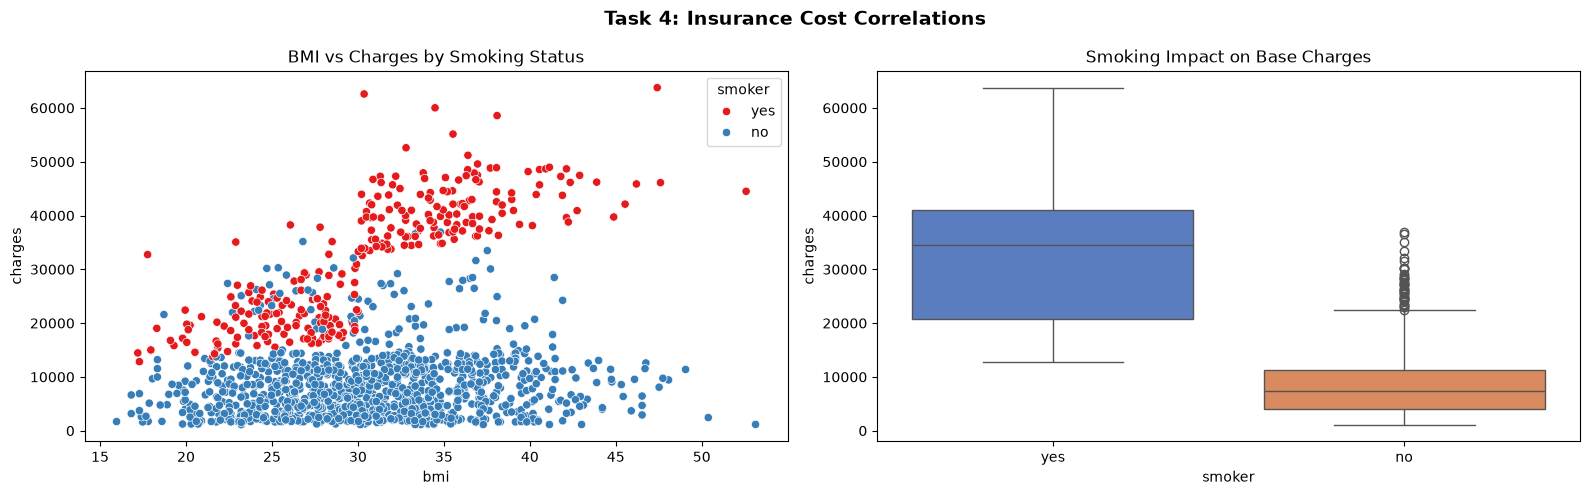

=== Task 4: Regression Error Evaluation ===
Mean Absolute Error (MAE): $4181.19
Root Mean Squared Error (RMSE): $5796.28
R-squared Score (R²): 0.7836


In [7]:
# ==============================================================================
# Task 4: Predicting Insurance Claim Amounts
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
df_ins = pd.read_csv("insurance.csv")

# 1. Visualize feature correlations & impacts
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Task 4: Insurance Cost Correlations", fontsize=14, weight='bold')
sns.scatterplot(data=df_ins, x='bmi', y='charges', hue='smoker', palette='Set1', ax=axes[0])
axes[0].set_title("BMI vs Charges by Smoking Status")
sns.boxplot(data=df_ins, x='smoker', y='charges', palette='muted', ax=axes[1], hue='smoker', legend=False)
axes[1].set_title("Smoking Impact on Base Charges")
plt.tight_layout()
plt.show()

# 2. Preprocessing & Encoding
df_ins_encoded = pd.get_dummies(df_ins, columns=['sex', 'smoker', 'region'], drop_first=True)

X = df_ins_encoded.drop(columns=['charges'])
y = df_ins_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train Linear Regression Model
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

# 4. Predict & Evaluate Metrics
y_pred = reg_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== Task 4: Regression Error Evaluation ===")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R-squared Score (R²): {r2:.4f}")